In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, TwoSlopeNorm

In [135]:
# Load the data from the file
data_conv = np.loadtxt('v0.6.0_nodeis/ddm_conv_bestfit.dat')

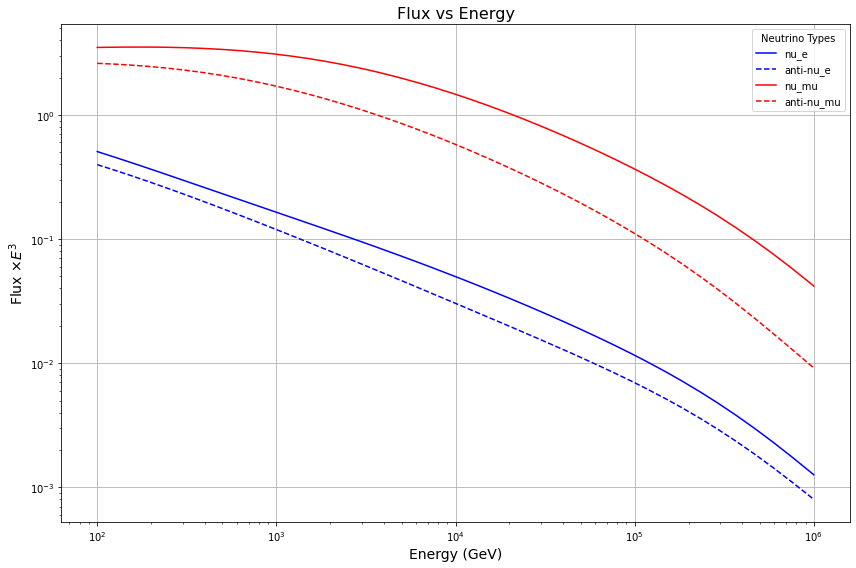

In [139]:
data = np.loadtxt('v0.6.0_nodeis/ddm_conv_bestfit.dat')#np.loadtxt("v0.6.0_nodeis/ddm_he_K-.dat")
# Extract the relevant columns
cos_zenith = data[:, 0]  # Cosine of zenith angle (Column 1)
energy = data[:, 1]      # Energy (Column 2)
energy_log = np.log10(energy)  # Logarithm of energy
flux_columns = data[:, 2:]     # All columns from Column 3 onward
df = pd.DataFrame(data, columns=["costhz", "E", "nu_e", "anti-nu_e", "nu_mu", "anti-nu_mu", "nu_tau", "anti-nu_tau"])
df_E = df.drop(columns='costhz').groupby("E").agg("sum").reset_index()

flavors = ["nu_e", "nu_mu"]
colors = ['b', 'r']

# Set up the plot
plt.figure(figsize=(12, 8))

# Plot each flux column against energy in the same plot
for i in range(len(flavors)):
    flv = flavors[i]
    plt.plot(df_E["E"], df_E["E"]**3*df_E[flv], label=flv, c=colors[i], ls="solid")
    plt.plot(df_E["E"], df_E["E"]**3*df_E["anti-"+flv], label="anti-"+flv, c=colors[i], ls="dashed")

plt.xscale('log') 
plt.yscale('log')
# Add plot title and labels
plt.title("Flux vs Energy", fontsize=16)
plt.xlabel("Energy (GeV)", fontsize=14)
plt.ylabel(r"Flux $\times E^3$", fontsize=14)
plt.yscale("log")  # Optional: Set y-axis to log scale for better visualization
plt.legend(title="Neutrino Types")
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

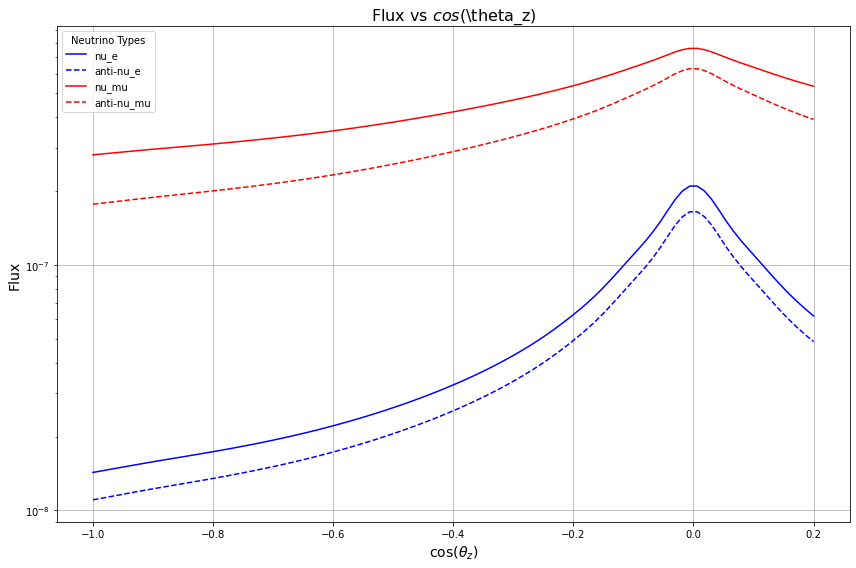

In [103]:
# Load the data from the file
data = np.loadtxt('v0.6.0_nodeis/ddm_conv_bestfit.dat')

# Extract the relevant columns
cos_zenith = data[:, 0]  # Cosine of zenith angle (Column 1)
energy = data[:, 1]      # Energy (Column 2)
energy_log = np.log10(energy)  # Logarithm of energy
flux_columns = data[:, 2:]     # All columns from Column 3 onward
df = pd.DataFrame(data, columns=["costhz", "E", "nu_e", "anti-nu_e", "nu_mu", "anti-nu_mu", "nu_tau", "anti-nu_tau"])
df_cos = df.drop(columns='E').groupby("costhz").agg("sum").reset_index()

flavors = ["nu_e", "nu_mu"]
colors = ['b', 'r']

# Set up the plot
plt.figure(figsize=(12, 8))

# Plot each flux column against energy in the same plot
for i in range(len(flavors)):
    flv = flavors[i]
    plt.plot(df_cos["costhz"], df_cos[flv], label=flv, c=colors[i], ls="solid")
    plt.plot(df_cos["costhz"], df_cos["anti-"+flv], label="anti-"+flv, c=colors[i], ls="dashed")

plt.yscale('log')
# Add plot title and labels
plt.title(r"Flux vs $cos($\theta_z$)$", fontsize=16)
plt.xlabel(r"cos($\theta_z$)", fontsize=14)
plt.ylabel(r"Flux", fontsize=14)
plt.yscale("log")  # Optional: Set y-axis to log scale for better visualization
plt.legend(title="Neutrino Types")
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

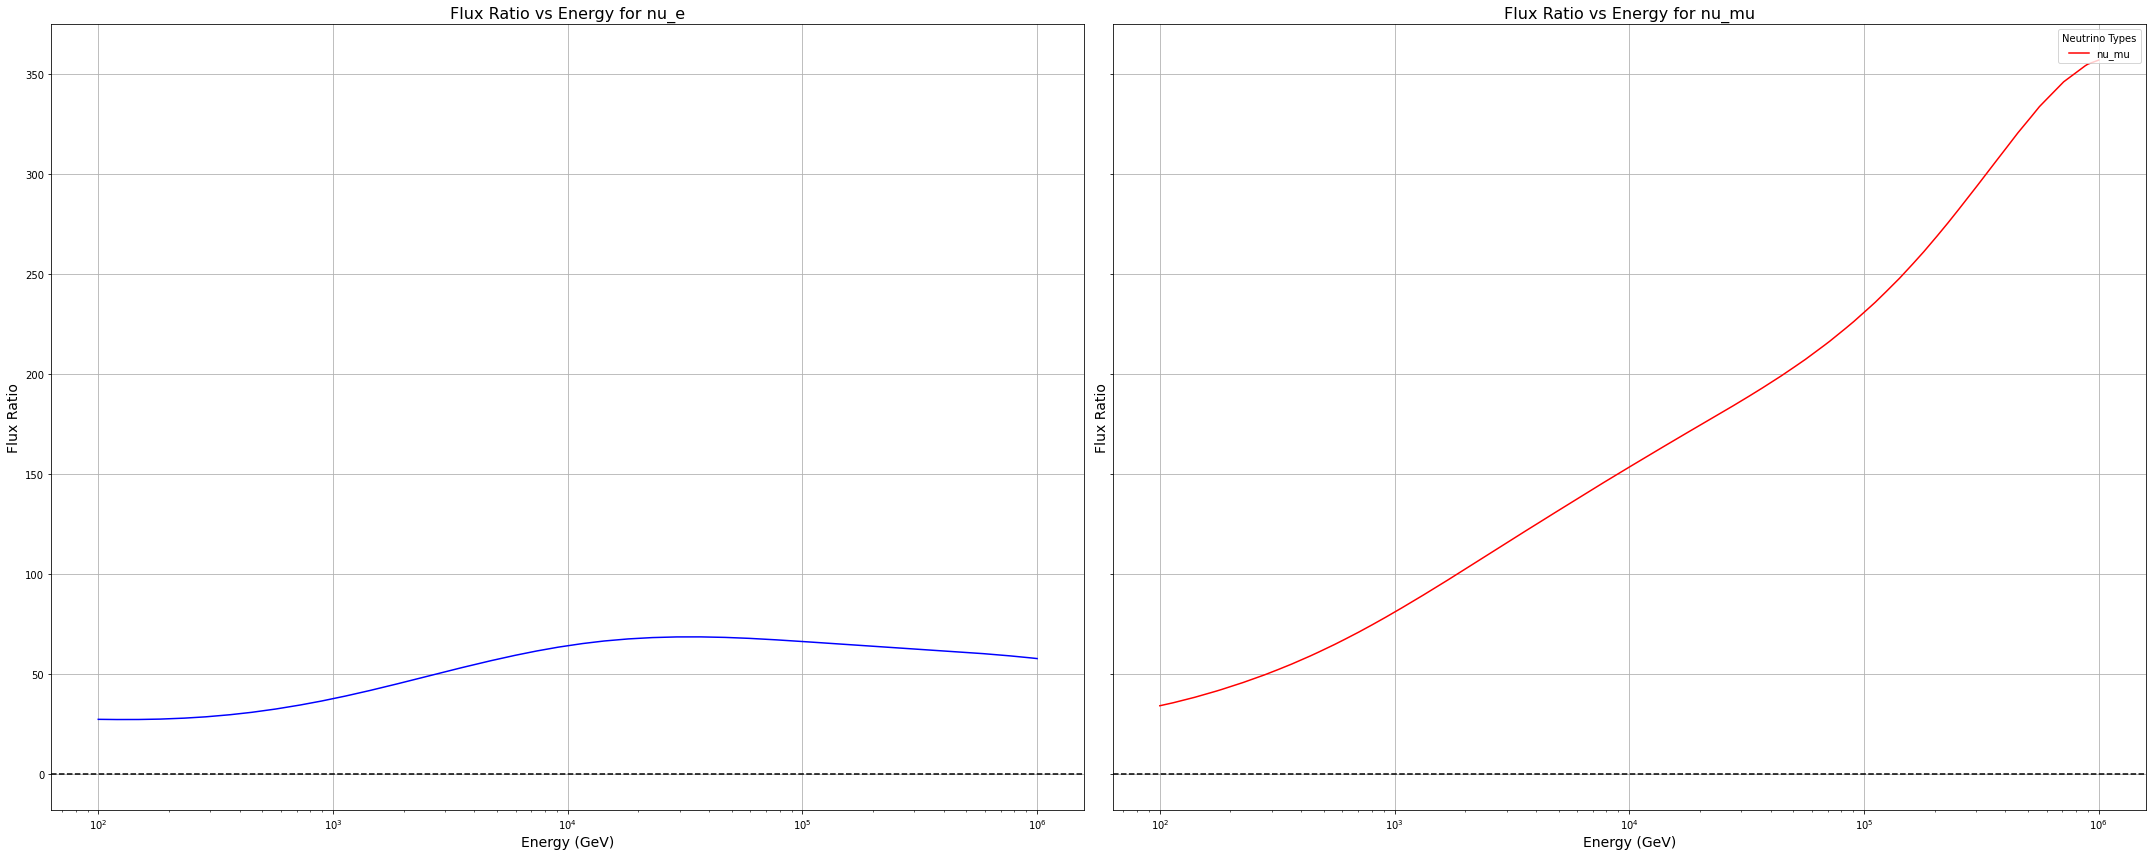

In [108]:
# Load the data from the file
data = np.loadtxt('v0.6.0_nodeis/ddm_conv_bestfit.dat')

# Create a DataFrame
df = pd.DataFrame(data, columns=["costhz", "E", "nu_e", "anti-nu_e", "nu_mu", "anti-nu_mu", "nu_tau", "anti-nu_tau"])

# Drop 'costhz' and group by 'E', summing the other columns
df_E = df.drop(columns='costhz').groupby("E").agg("sum").reset_index()

# Define the flavors and their corresponding colors
flavors = ["nu_e", "nu_mu"]
colors = ['b', 'r']

# Set up subplots for each flavor
fig, axs = plt.subplots(1, len(flavors), figsize=(30, 12), sharey=True)

# Iterate over each flavor and create a log-log plot
for i, flavor in enumerate(flavors):
    # Plot for neutrino
    axs[i].plot(df_E["E"], df_E[flavor]/df_E["anti-"+flavor]*100 - 100, label=flavor, color=colors[i], linestyle='solid')
    axs[i].axhline(y=0, color='k', linestyle='--')
    
    # Set logarithmic scales
    axs[i].set_xscale('log')
    
    # Set title and labels
    axs[i].set_title(f"Flux Ratio vs Energy for {flavor}", fontsize=16)
    axs[i].set_ylabel("Flux Ratio", fontsize=14)
    axs[i].set_xlabel("Energy (GeV)", fontsize=14)
    axs[i].grid(True)


plt.legend(title="Neutrino Types", loc='upper right')
plt.tight_layout()

# Show the plots
plt.show()


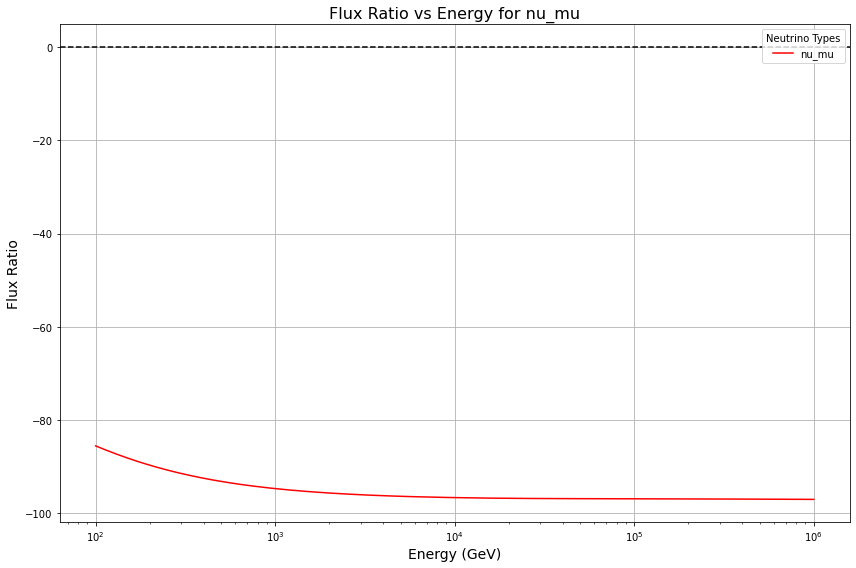

In [112]:
data = np.loadtxt('v0.6.0_nodeis/ddm_conv_bestfit.dat')


# Create a DataFrame
df = pd.DataFrame(data, columns=["costhz", "E", "nu_e", "anti-nu_e", "nu_mu", "anti-nu_mu", "nu_tau", "anti-nu_tau"])

# Drop 'costhz' and group by 'E', summing the other columns
df_E = df.drop(columns='costhz').groupby("E").agg("sum").reset_index()

# Define the flavors and their corresponding colors
flavors = ["nu_e", "nu_mu"]
colors = ['b', 'r']

# Set up subplots for each flavor
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Iterate over each flavor and create a log-log plot

ax.plot(df_E["E"], df_E[flavors[0]]/df_E[flavors[1]]*100 - 100, label=flavor, color=colors[i], linestyle='solid')
ax.axhline(y=0, color='k', linestyle='--')

# Set logarithmic scales
ax.set_xscale('log')

# Set title and labels
ax.set_title(f"Flux Ratio vs Energy for {flavor}", fontsize=16)
ax.set_ylabel("Flux Ratio", fontsize=14)
ax.set_xlabel("Energy (GeV)", fontsize=14)
ax.grid(True)




plt.legend(title="Neutrino Types", loc='upper right')
plt.tight_layout()

# Show the plots
plt.show()


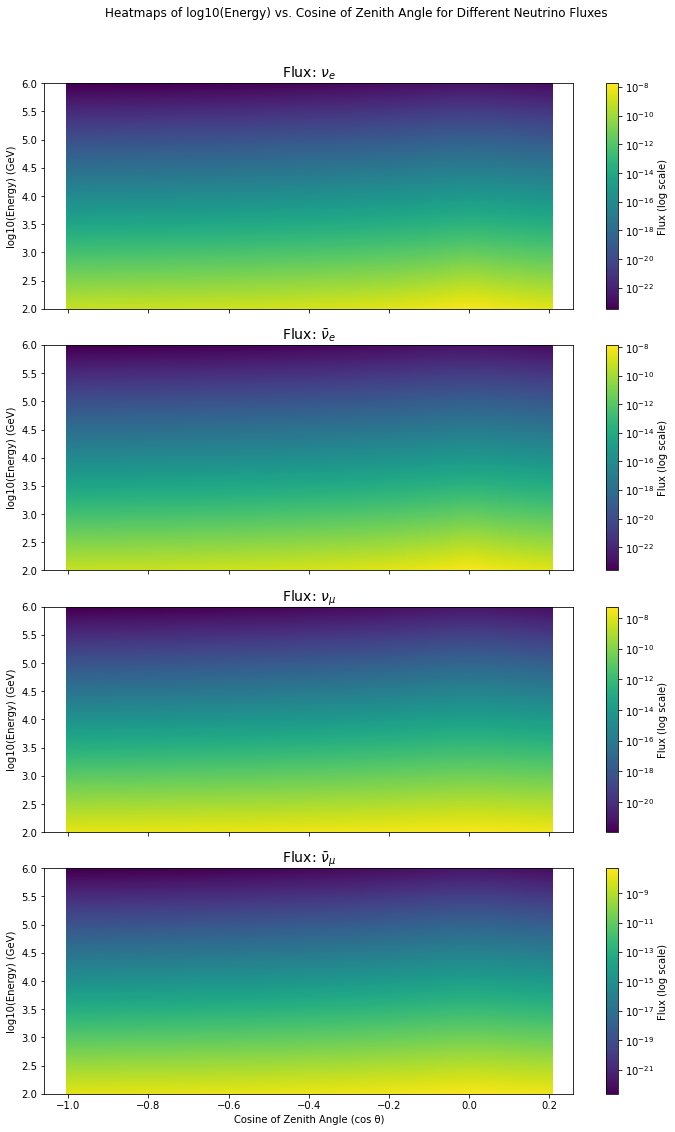

In [134]:
# Load the data from the file
data = np.loadtxt('v0.6.0_nodeis/ddm_conv_bestfit.dat')

# Extract the relevant columns
cos_zenith = data[:, 0]  # Cosine of zenith angle (Column 1)
energy = data[:, 1]      # Energy (Column 2)
energy_log = np.log10(energy)  # Logarithm of energy
flux_columns = data[:, 2:6]     # All columns from Column 3 onward
flux_dir = {
    2 : r"\nu_e",
    3 : r"\bar{\nu}_e",
    4 : r"\nu_\mu",
    5 : r"\bar{\nu}_\mu"
}
# Number of columns to plot
num_columns = flux_columns.shape[1]

# Set up subplots with one row per column
fig, axs = plt.subplots(num_columns, 1, figsize=(10, 4 * num_columns), sharex=True, sharey=True)
fig.suptitle("Heatmaps of log10(Energy) vs. Cosine of Zenith Angle for Different Neutrino Fluxes")

# Iterate over each column and plot the heatmap
for i in range(num_columns):
    ax = axs[i] if num_columns > 1 else axs  # Handle case for a single column gracefully

 
    sc = ax.scatter(cos_zenith, energy_log, c=flux_columns[:, i], cmap='viridis', marker='s', s=20,
                    norm=LogNorm(vmin=flux_columns[:, i].min(), vmax=flux_columns[:, i].max()))
    ax.set_title(rf"Flux: ${flux_dir[i+2]}$", fontsize=14)
    ax.set_ylabel("log10(Energy) (GeV)")
    ax.set_ylim(bottom=np.min(energy_log), top=6)

    # Add a colorbar for each subplot
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Flux (log scale)")

# Set common x-axis label
plt.xlabel("Cosine of Zenith Angle (cos θ)")

# Adjust layout for readability
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the figure
plt.show()


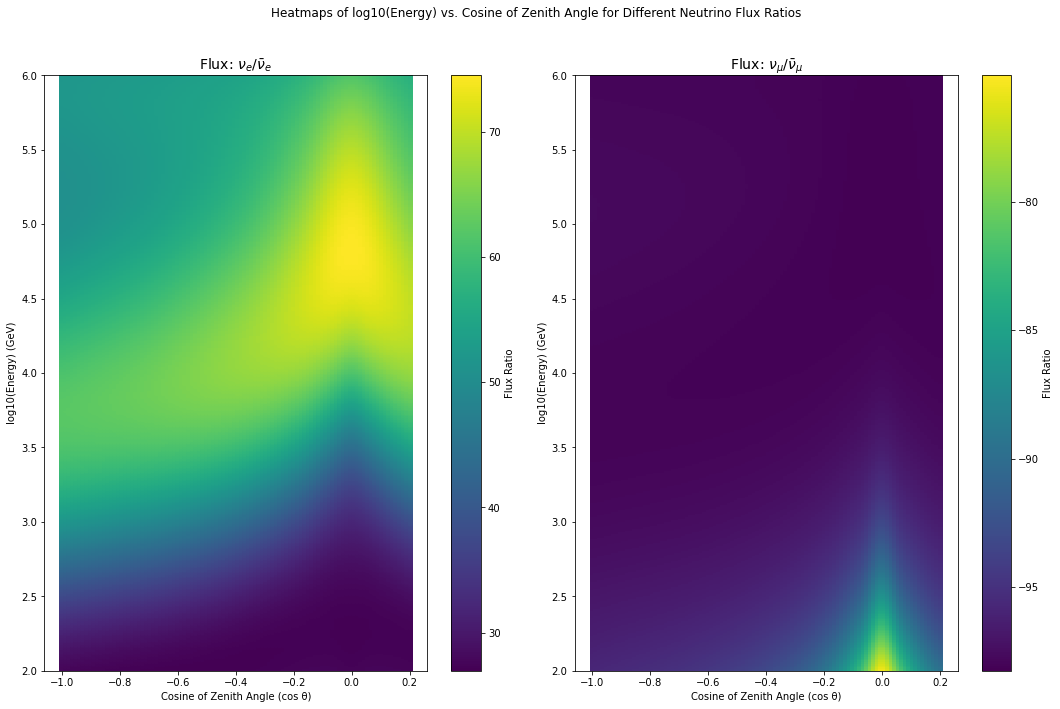

In [133]:
# Load the data from the file
data = np.loadtxt('v0.6.0_nodeis/ddm_conv_bestfit.dat')

# Extract the relevant columns
cos_zenith = data[:, 0]  # Cosine of zenith angle (Column 1)
energy = data[:, 1]      # Energy (Column 2)
energy_log = np.log10(energy)  # Logarithm of energy
flux_columns = data[:, 2:6]     # All columns from Column 3 onward
flux_ratios_dir = {
    1 : r"\nu_e / \bar{\nu}_e",
    2 : r"\nu_\mu / \bar{\nu}_\mu"
}
# Number of columns to plot
num_columns = flux_columns.shape[1]

# Set up subplots with one row per column
fig, axs = plt.subplots(1, int(num_columns/2), figsize=(15, 10), sharex=False, sharey=False)
fig.suptitle("Heatmaps of log10(Energy) vs. Cosine of Zenith Angle for Different Neutrino Flux Ratios")

# Iterate over each column and plot the heatmap
for i in range(int(num_columns/2)):
    ax = axs[i] if num_columns > 1 else axs  # Handle case for a single column gracefully
    
    color_values = (flux_columns[:, i] / flux_columns[:, i + 1] * 100) - 100

    sc = ax.scatter(cos_zenith, np.log10(energy), c=color_values, cmap='viridis', vmin=color_values.min(), vmax=color_values.max(), marker='s', s=20)
    ax.set_title(rf"Flux: ${flux_ratios_dir[i+1]}$", fontsize=14)
    ax.set_ylabel("log10(Energy) (GeV)")
    ax.set_ylim(bottom=np.min(energy_log), top=6)
    ax.set_xlabel("Cosine of Zenith Angle (cos θ)")

    # Add a colorbar for each subplot
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Flux Ratio")

# Adjust layout for readability
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the figure
plt.show()


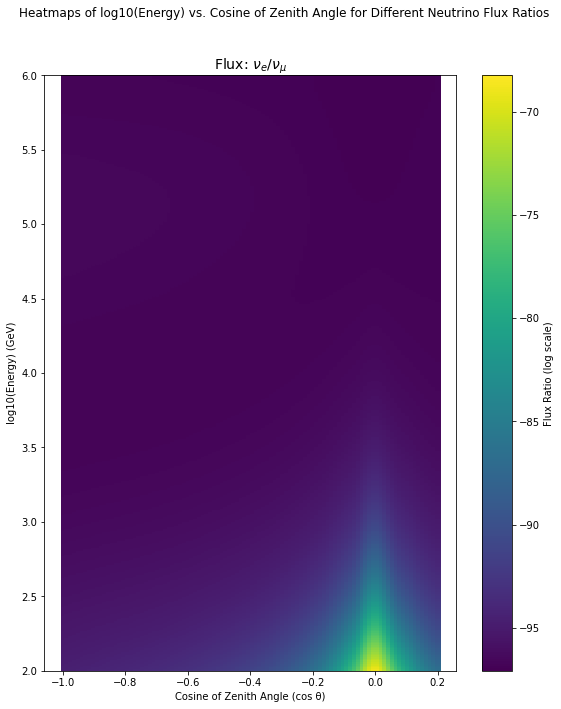

In [131]:
# Load the data from the file
data = np.loadtxt('v0.6.0_nodeis/ddm_conv_bestfit.dat')

# Extract the relevant columns
cos_zenith = data[:, 0]  # Cosine of zenith angle (Column 1)
energy = data[:, 1]      # Energy (Column 2)
energy_log = np.log10(energy)  # Logarithm of energy
flux_columns = data[:, 2:]     # All columns from Column 3 onward
flux_columns_nu = flux_columns[:, 0:-1:2]
flux_ratios_dir = {
    1 : r"\nu_e / \nu_\mu",
}
# Number of columns to plot
num_columns = flux_columns.shape[1]

# Set up subplots with one row per column
fig, ax = plt.subplots(1, figsize=(8, 10), sharex=False, sharey=False)
fig.suptitle("Heatmaps of log10(Energy) vs. Cosine of Zenith Angle for Different Neutrino Flux Ratios")

# Iterate over each column and plot the heatmap


color_values = flux_columns_nu[:, 0]/flux_columns_nu[:, 1]*100 - 100
sc = ax.scatter(cos_zenith, np.log10(energy), c=color_values, cmap='viridis', vmin=color_values.min(), vmax=color_values.max(), marker='s', s=20)
#sc = axs[0].scatter(cos_zenith, energy_log, c=(flux_columns_nu[:, 0]/flux_columns_nu[:, 1]*100 - 100), cmap='viridis', marker='s', s=20)
ax.set_title(rf"Flux: ${flux_ratios_dir[1]}$", fontsize=14)
ax.set_ylabel("log10(Energy) (GeV)")
ax.set_ylim(bottom=np.min(energy_log), top=6)
ax.set_xlabel("Cosine of Zenith Angle (cos θ)")

# Add a colorbar for each subplot
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Flux Ratio (log scale)")

# Adjust layout for readability
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the figure
plt.show()
